<a href="https://colab.research.google.com/github/marsanla/C4L/blob/main/SOL_C4L_6_Ejercicio_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Soluciones — Módulo 6: Proyecto final integrador

> Solución completa del **sistema de alertas y reporting** para un despacho de abogados. El proyecto integra todo lo aprendido: funciones, archivos, fechas, pandas, matplotlib, JSON, manejo de errores y prompt engineering como ayuda opcional.

### Estructura

1. **Carga y análisis de datos** — leer CSV, calcular días restantes, ordenar.
2. **Sistema de alertas** — detectar plazos próximos, generar mensajes (en este SOL no enviamos emails reales).
3. **Generación de informes** — CSV y PDF.
4. **Visualización** — gráficos comparativos por abogado y por estado de caso.

### Cómo está organizada la solución

| Función | Responsabilidad |
| --- | --- |
| `cargar_datos` | Lee el CSV y ajusta tipos. |
| `calcular_fechas_limite` | Añade columnas con días restantes. |
| `analizar_fechas` | Genera la gráfica comparativa. |
| `revisar_fechas_y_enviar_alertas` | Detecta vencimientos próximos (sin enviar email). |
| `generar_informe_csv` | Exporta el DataFrame a CSV. |
| `generar_informe_pdf` | Exporta el DataFrame a PDF. |
| `grafico_casos_presentados_vs_vencidos_y_pendientes` | Gráfico de barras agregado. |
| `grafico_rendimiento_abogados` | Gráfico de barras por abogado. |


### Preparación — generar datos de ejemplo


In [1]:
import pandas as pd
import re
import random
from datetime import datetime, timedelta

random.seed(42)   # reproducibilidad


def to_snake_case(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9]+', '_', text)
    return text.strip('_')


def generar_datos_casos(num_casos=60):
    """Genera un DataFrame con datos simulados de casos legales."""
    abogados = ["Juan Perez", "Ana Gomez", "Carlos Ruiz", "Laura Martin"]
    tipos = ["Civil", "Penal", "Comercial", "Laboral", "Familia"]
    estados = ["Pendiente", "Resuelto"]

    filas = []
    for i in range(num_casos):
        fecha_inicio = datetime.now() - timedelta(days=random.randint(30, 365))
        fase1 = fecha_inicio + timedelta(days=random.randint(20, 60))
        fase2 = fase1 + timedelta(days=random.randint(20, 60))
        filas.append({
            "CasoID":             1000 + i,
            "Abogado":            random.choice(abogados),
            "TipoCaso":           random.choice(tipos),
            "ValorDisputa":       random.randint(5_000, 200_000),
            "HorasDedicadas":     random.randint(5, 200),
            "FechaInicio":        fecha_inicio.strftime("%Y-%m-%d"),
            "FechaLimiteFase1":   fase1.strftime("%Y-%m-%d"),
            "FechaLimiteFase2":   fase2.strftime("%Y-%m-%d"),
            "Estado":             random.choice(estados),
        })
    return pd.DataFrame(filas)


df = generar_datos_casos()
df.to_csv("casos.csv", index=False)
print(f"Generado 'casos.csv' con {len(df)} registros.")
df.head()


Generado 'casos.csv' con 60 registros.


,CasoID,Abogado,TipoCaso,ValorDisputa,HorasDedicadas,FechaInicio,FechaLimiteFase1,FechaLimiteFase2,Estado
0,1000,Carlos Ruiz,Penal,63513,40,2025-05-08,2025-06-04,2025-06-25,Pendiente
1,1001,Laura Martin,Civil,12811,28,2025-06-25,2025-07-20,2025-09-15,Pendiente
2,1002,Juan Perez,Familia,57124,188,2025-12-02,2026-01-23,2026-03-22,Resuelto
3,1003,Carlos Ruiz,Civil,46853,183,2025-12-09,2026-01-26,2026-03-24,Resuelto
4,1004,Ana Gomez,Comercial,31793,28,2025-10-08,2025-11-14,2025-12-13,Resuelto


## 1. Carga y análisis de datos


In [2]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt


def cargar_datos(archivo_csv):
    """Carga el CSV y convierte las columnas de fecha a datetime."""
    df = pd.read_csv(archivo_csv)
    columnas_fecha = ["FechaInicio", "FechaLimiteFase1", "FechaLimiteFase2"]
    for col in columnas_fecha:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


datos = cargar_datos("casos.csv")
print("Tipos:")
print(datos.dtypes)
datos.head()


Tipos:
CasoID                       int64
Abogado                     object
TipoCaso                    object
ValorDisputa                 int64
HorasDedicadas               int64
FechaInicio         datetime64[ns]
FechaLimiteFase1    datetime64[ns]
FechaLimiteFase2    datetime64[ns]
Estado                      object
dtype: object


,CasoID,Abogado,TipoCaso,ValorDisputa,HorasDedicadas,FechaInicio,FechaLimiteFase1,FechaLimiteFase2,Estado
0,1000,Carlos Ruiz,Penal,63513,40,2025-05-08,2025-06-04,2025-06-25,Pendiente
1,1001,Laura Martin,Civil,12811,28,2025-06-25,2025-07-20,2025-09-15,Pendiente
2,1002,Juan Perez,Familia,57124,188,2025-12-02,2026-01-23,2026-03-22,Resuelto
3,1003,Carlos Ruiz,Civil,46853,183,2025-12-09,2026-01-26,2026-03-24,Resuelto
4,1004,Ana Gomez,Comercial,31793,28,2025-10-08,2025-11-14,2025-12-13,Resuelto


In [3]:
def calcular_fechas_limite(datos):
    """Añade columnas con los días restantes hasta cada fase."""
    ahora = datetime.now()
    datos = datos.copy()
    datos["dias_restantes_fase1"] = (datos["FechaLimiteFase1"] - ahora).dt.days
    datos["dias_restantes_fase2"] = (datos["FechaLimiteFase2"] - ahora).dt.days

    # Ordenar por urgencia (la fase 1 manda)
    datos = datos.sort_values(["dias_restantes_fase1", "dias_restantes_fase2"])
    return datos


datos_analizados = calcular_fechas_limite(datos)
datos_analizados.head()


,CasoID,Abogado,TipoCaso,ValorDisputa,HorasDedicadas,FechaInicio,FechaLimiteFase1,FechaLimiteFase2,Estado,dias_restantes_fase1,dias_restantes_fase2
29,1029,Laura Martin,Comercial,33644,68,2025-05-01,2025-05-27,2025-06-19,Pendiente,-339,-316
0,1000,Carlos Ruiz,Penal,63513,40,2025-05-08,2025-06-04,2025-06-25,Pendiente,-331,-310
38,1038,Carlos Ruiz,Comercial,58545,176,2025-05-18,2025-06-12,2025-07-28,Resuelto,-323,-277
50,1050,Ana Gomez,Penal,113080,11,2025-05-18,2025-06-16,2025-07-21,Pendiente,-319,-284
18,1018,Ana Gomez,Penal,103019,200,2025-05-15,2025-06-23,2025-08-22,Pendiente,-312,-252


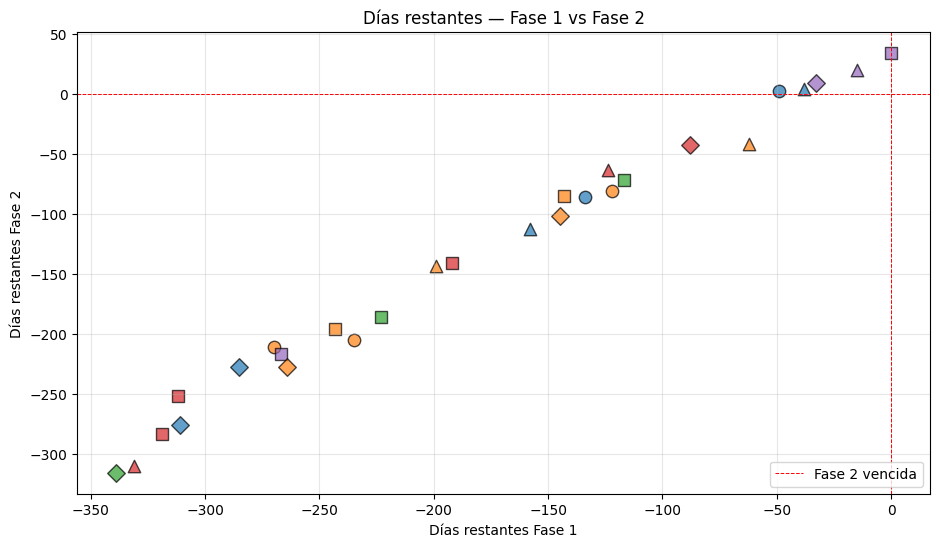

In [4]:
def analizar_fechas(datos):
    """Genera una gráfica comparando los días restantes de fase1 y fase2."""
    color_map = {
        "Civil": "tab:blue", "Penal": "tab:red", "Comercial": "tab:green",
        "Laboral": "tab:purple", "Familia": "tab:orange"
    }
    marker_map = {
        "Juan Perez": "o", "Ana Gomez": "s",
        "Carlos Ruiz": "^", "Laura Martin": "D"
    }

    plt.figure(figsize=(11, 6))
    for _, row in datos.iterrows():
        plt.scatter(
            row["dias_restantes_fase1"],
            row["dias_restantes_fase2"],
            c=color_map.get(row["TipoCaso"], "gray"),
            marker=marker_map.get(row["Abogado"], "x"),
            s=80,
            edgecolors="black",
            alpha=0.7,
        )

    plt.axhline(0, color="red", linestyle="--", linewidth=0.7, label="Fase 2 vencida")
    plt.axvline(0, color="red", linestyle="--", linewidth=0.7)

    plt.title("Días restantes — Fase 1 vs Fase 2")
    plt.xlabel("Días restantes Fase 1")
    plt.ylabel("Días restantes Fase 2")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="lower right")
    plt.show()


# Solo casos pendientes
datos_pendientes = datos_analizados[datos_analizados["Estado"] == "Pendiente"].copy()
analizar_fechas(datos_pendientes)


## 2. Sistema de alertas

> En esta solución NO enviamos email real (requeriría credenciales de servidor SMTP). En su lugar, **simulamos** la generación de la alerta imprimiendo lo que se enviaría. La estructura del código es exactamente la misma: cuando tengas las credenciales, basta con sustituir `print(...)` por `enviar_email(...)`.


In [5]:
def revisar_fechas_y_enviar_alertas(datos, dias_aviso=7):
    """Genera alertas para casos cuya fase1 o fase2 vence en <= dias_aviso."""
    alertas_generadas = 0

    for _, caso in datos.iterrows():
        d1 = caso["dias_restantes_fase1"]
        d2 = caso["dias_restantes_fase2"]

        if (0 <= d1 <= dias_aviso) or (0 <= d2 <= dias_aviso):
            mensaje = (
                f"AVISO — Caso {caso['CasoID']} ({caso['TipoCaso']})\n"
                f"  Abogado responsable: {caso['Abogado']}\n"
                f"  Días restantes Fase 1: {d1}\n"
                f"  Días restantes Fase 2: {d2}\n"
                f"  Valor en disputa: {caso['ValorDisputa']:,}€\n"
            )
            print(mensaje)
            alertas_generadas += 1

    print(f"Total alertas generadas: {alertas_generadas}")
    return alertas_generadas


revisar_fechas_y_enviar_alertas(datos_pendientes)


AVISO — Caso 1014 (Civil)
  Abogado responsable: Juan Perez
  Días restantes Fase 1: -49
  Días restantes Fase 2: 2
  Valor en disputa: 33,743€

AVISO — Caso 1005 (Civil)
  Abogado responsable: Carlos Ruiz
  Días restantes Fase 1: -38
  Días restantes Fase 2: 4
  Valor en disputa: 196,294€

AVISO — Caso 1052 (Laboral)
  Abogado responsable: Ana Gomez
  Días restantes Fase 1: 0
  Días restantes Fase 2: 34
  Valor en disputa: 96,660€

Total alertas generadas: 3


3

## 3. Generación de informes


In [6]:
def generar_informe_csv(datos, archivo_csv="informe_casos.csv"):
    """Guarda el DataFrame como CSV."""
    datos.to_csv(archivo_csv, index=False)
    print(f"Informe CSV guardado en: {archivo_csv}")


generar_informe_csv(datos_pendientes)


Informe CSV guardado en: informe_casos.csv


In [7]:
# Para PDF usamos matplotlib (siempre disponible). FPDF también vale.
from matplotlib.backends.backend_pdf import PdfPages

def generar_informe_pdf(datos, archivo_pdf="informe_casos.pdf"):
    """Genera un PDF con un resumen agregado y una tabla de casos."""
    with PdfPages(archivo_pdf) as pdf:

        # Página 1 — Resumen
        total = len(datos)
        urgentes = len(datos[(datos["dias_restantes_fase1"] <= 7) |
                             (datos["dias_restantes_fase2"] <= 7)])
        valor_total = datos["ValorDisputa"].sum()

        fig, ax = plt.subplots(figsize=(8.27, 4))
        ax.axis("off")
        texto = (
            f"INFORME DE CASOS — {datetime.now().strftime('%d/%m/%Y')}\n\n"
            f"  Total casos:        {total}\n"
            f"  Casos urgentes:     {urgentes}\n"
            f"  Valor total cartera:{valor_total:,.2f}€"
        )
        ax.text(0.05, 0.5, texto, fontsize=12, family="monospace", va="center")
        pdf.savefig(fig)
        plt.close(fig)

        # Página 2 — Casos por tipo
        fig, ax = plt.subplots(figsize=(8, 4))
        datos["TipoCaso"].value_counts().plot(kind="bar", ax=ax, color="steelblue")
        ax.set_title("Casos por tipo")
        ax.set_xlabel("Tipo")
        ax.set_ylabel("Cantidad")
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

    print(f"Informe PDF guardado en: {archivo_pdf}")


generar_informe_pdf(datos_pendientes)


Informe PDF guardado en: informe_casos.pdf


## 4. Visualización


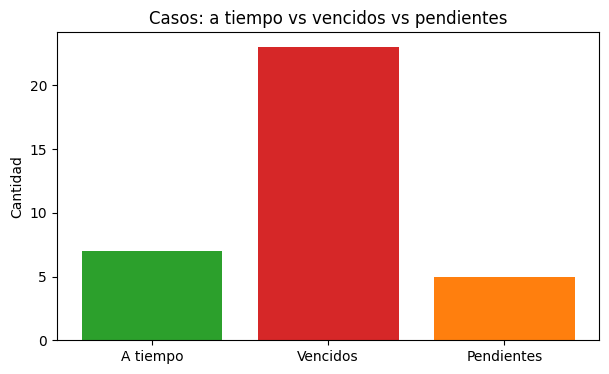

In [8]:
def grafico_casos_presentados_vs_vencidos_y_pendientes(datos):
    """Gráfico apilado: presentados a tiempo, vencidos y pendientes."""
    ahora = datetime.now()

    presentados = (datos["FechaLimiteFase2"] >= ahora) & (datos["Estado"] == "Resuelto")
    vencidos    = (datos["FechaLimiteFase2"] <  ahora) & (datos["Estado"] == "Pendiente")
    pendientes  = (datos["FechaLimiteFase2"] >= ahora) & (datos["Estado"] == "Pendiente")

    counts = {
        "A tiempo":  presentados.sum(),
        "Vencidos":  vencidos.sum(),
        "Pendientes":pendientes.sum(),
    }

    plt.figure(figsize=(7, 4))
    plt.bar(counts.keys(), counts.values(),
            color=["tab:green", "tab:red", "tab:orange"])
    plt.title("Casos: a tiempo vs vencidos vs pendientes")
    plt.ylabel("Cantidad")
    plt.show()


grafico_casos_presentados_vs_vencidos_y_pendientes(cargar_datos("casos.csv"))


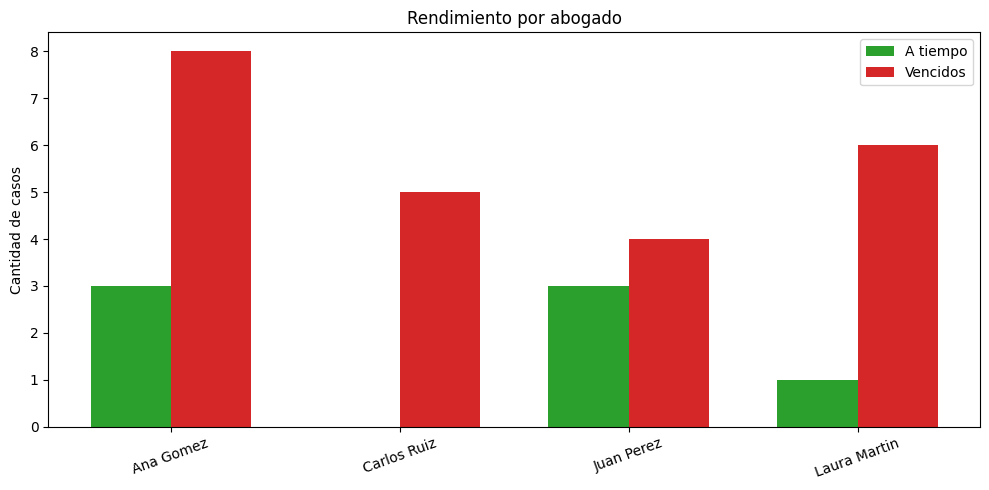

In [9]:
def grafico_rendimiento_abogados(datos):
    """Gráfico de barras agrupadas: por abogado, casos a tiempo vs vencidos."""
    ahora = datetime.now()

    abogados = sorted(datos["Abogado"].unique())
    a_tiempo  = []
    vencidos  = []

    for abogado in abogados:
        sub = datos[datos["Abogado"] == abogado]
        a_tiempo.append(((sub["FechaLimiteFase2"] >= ahora) &
                         (sub["Estado"] == "Resuelto")).sum())
        vencidos.append(((sub["FechaLimiteFase2"] <  ahora) &
                         (sub["Estado"] == "Pendiente")).sum())

    import numpy as np
    x = np.arange(len(abogados))
    ancho = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - ancho/2, a_tiempo, ancho, label="A tiempo", color="tab:green")
    plt.bar(x + ancho/2, vencidos, ancho, label="Vencidos", color="tab:red")
    plt.xticks(x, abogados, rotation=20)
    plt.title("Rendimiento por abogado")
    plt.ylabel("Cantidad de casos")
    plt.legend()
    plt.tight_layout()
    plt.show()


grafico_rendimiento_abogados(cargar_datos("casos.csv"))


## 5. Función `main` que orquesta todo el sistema


SISTEMA DE GESTIÓN DE CASOS

Cargados 60 casos.
   De ellos, 28 están pendientes.

--- ALERTAS ---
AVISO — Caso 1014 (Civil)
  Abogado responsable: Juan Perez
  Días restantes Fase 1: -49
  Días restantes Fase 2: 2
  Valor en disputa: 33,743€

AVISO — Caso 1005 (Civil)
  Abogado responsable: Carlos Ruiz
  Días restantes Fase 1: -38
  Días restantes Fase 2: 4
  Valor en disputa: 196,294€

AVISO — Caso 1052 (Laboral)
  Abogado responsable: Ana Gomez
  Días restantes Fase 1: 0
  Días restantes Fase 2: 34
  Valor en disputa: 96,660€

Total alertas generadas: 3

--- INFORMES ---
Informe CSV guardado en: informe_pendientes.csv
Informe PDF guardado en: informe_pendientes.pdf

--- VISUALIZACIÓN ---


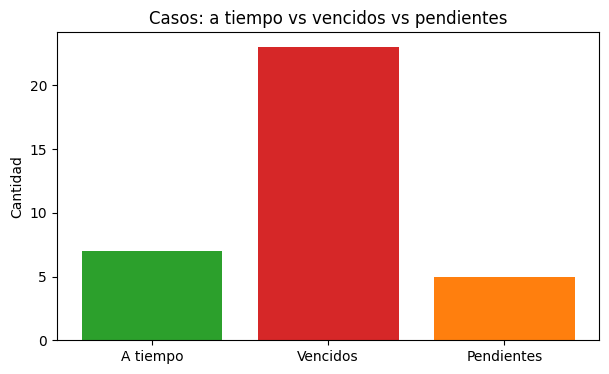

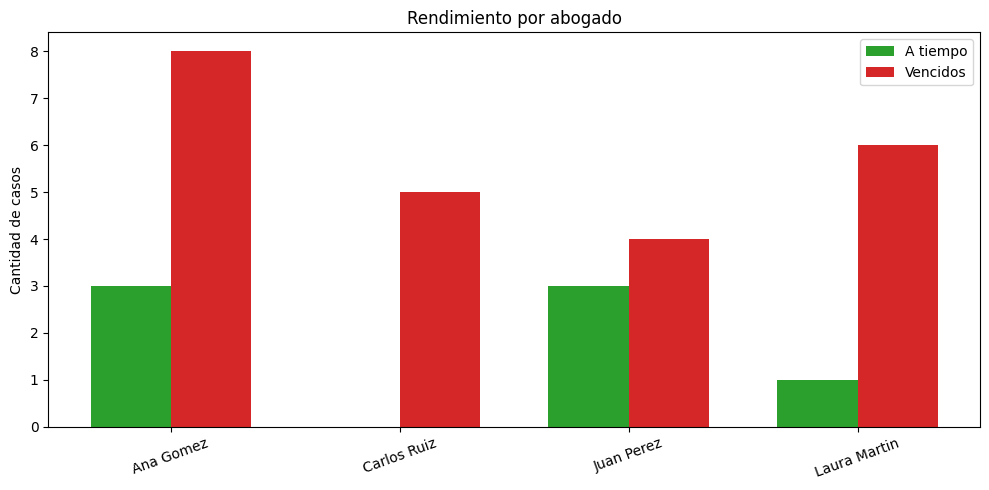


=== Pipeline completo ===


In [10]:
def main(archivo_csv="casos.csv"):
    """Pipeline completo del sistema de gestión."""
    print("=" * 60)
    print("SISTEMA DE GESTIÓN DE CASOS")
    print("=" * 60)

    # 1. Cargar
    datos = cargar_datos(archivo_csv)
    print(f"\nCargados {len(datos)} casos.")

    # 2. Calcular fechas
    datos = calcular_fechas_limite(datos)

    # 3. Filtrar pendientes
    pendientes = datos[datos["Estado"] == "Pendiente"].copy()
    print(f"   De ellos, {len(pendientes)} están pendientes.")

    # 4. Alertas
    print("\n--- ALERTAS ---")
    revisar_fechas_y_enviar_alertas(pendientes)

    # 5. Informes
    print("\n--- INFORMES ---")
    generar_informe_csv(pendientes, "informe_pendientes.csv")
    generar_informe_pdf(pendientes, "informe_pendientes.pdf")

    # 6. Visualización
    print("\n--- VISUALIZACIÓN ---")
    grafico_casos_presentados_vs_vencidos_y_pendientes(datos)
    grafico_rendimiento_abogados(datos)

    print("\n=== Pipeline completo ===")


main()


## Cierre del curso

¡Enhorabuena! Si has llegado hasta aquí con todo funcionando, has completado el curso **Coding for Lawyers** y has demostrado a ti mismo/a que la programación **no es exclusiva del perfil técnico**.

### Lo que te llevas

| Habilidad | Lo que puedes hacer ya |
| --- | --- |
| **Python** | Variables, tipos, fechas, métodos, condicionales, bucles, funciones, archivos. |
| **Manejo de datos** | Pandas, numpy, matplotlib para análisis y visualización. |
| **Automatización** | Pipelines completos: cargar → procesar → analizar → reportar. |
| **IA generativa** | Bases de prompt engineering aplicado al derecho. |

### Próximos pasos sugeridos

1. **Aplica lo aprendido** a una tarea concreta de tu día a día. La mejor forma de consolidar es resolviendo un problema real.
2. **Mantén una "carpeta de scripts"** con las funciones reutilizables que vayas creando.
3. **Sigue practicando** con proyectos propios y consulta la documentación oficial de Python, pandas y los proveedores de IA cuando necesites profundizar.

> Gracias por confiar en *Coding for Lawyers*. **Sigue programando.**